In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### (Symmetric) Quantization
Map real-valued numbers $ x \in \mathbb{R} $ to integers $q \in \mathbb{Z}$, e.g. 8-bit signed integers in $[-128, 127]$.

$q = \left \lfloor \frac{x}{s} + z\right \rfloor$

$x \approx \hat{x} = s \cdot (q - z)$ (s := scale, z := zero-point)

In [13]:
np.set_printoptions(precision=4, suppress=True)
x = np.linspace(-1.0, 1.0, 10, dtype=np.float32)
print("Original float32 values:\n", x)

qmin, qmax = -128, 127
x_min, x_max = x.min(), x.max()
x_abs_max = max(abs(x_min), abs(x_max))

scale = x_abs_max / 127.0  # symmetric
zero_point = 0             # symmetric

print("Scale:", scale, "Zero-point:", zero_point)

q = np.round(x / scale).astype(np.int32)
q = np.clip(q, qmin, qmax)
print("Quantized int values:\n", q)

x_hat = scale * (q - zero_point)
print("Dequantized float values:\n", x_hat)

error = x - x_hat
print("Quantization error:\n", error)
print("Mean squared error:", np.mean(error**2))

Original float32 values:
 [-1.     -0.7778 -0.5556 -0.3333 -0.1111  0.1111  0.3333  0.5556  0.7778
  1.    ]
Scale: 0.007874016 Zero-point: 0
Quantized int values:
 [-127  -99  -71  -42  -14   14   42   71   99  127]
Dequantized float values:
 [-1.     -0.7795 -0.5591 -0.3307 -0.1102  0.1102  0.3307  0.5591  0.7795
  1.    ]
Quantization error:
 [-0.      0.0017  0.0035 -0.0026 -0.0009  0.0009  0.0026 -0.0035 -0.0017
  0.    ]
Mean squared error: 4.592562633162767e-06


Error:  [-0.0065  0.007  -0.0077 ... -0.0027  0.0026  0.0034]
Scale: 0.015744949
MSE: 2.0895778886926502e-05
Max abs error: 0.007872186601161957


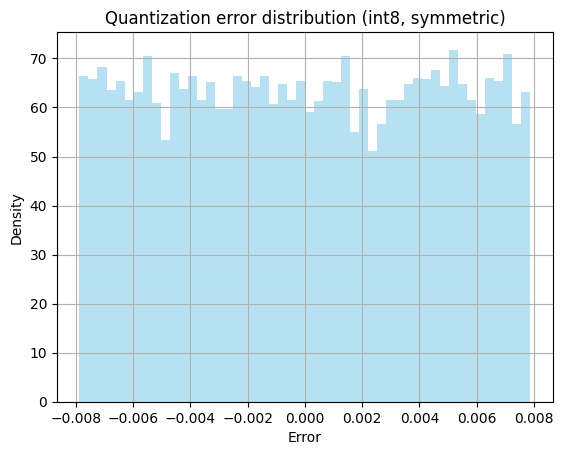

1.0000000000000007


In [ ]:
N = 10000
x = np.random.uniform(-2.0, 2.0, size=N).astype(np.float32)

x_min, x_max = x.min(), x.max()
x_abs_max = max(abs(x_min), abs(x_max))
scale = x_abs_max / 127.0
zero_point = 0

# Quantize and dequantize (symmetric, z = 0)
q = np.round(x / scale).astype(np.int32)
q = np.clip(q, -128, 127)
x_hat = scale * (q - zero_point)

error = x - x_hat
mse = np.mean(error**2)
max_abs_error = np.max(np.abs(error))

hist, bins = np.histogram(error, bins=50, density=True)
bin_width = bins[1] - bins[0]
area = np.sum(hist * bin_width)
print(area)   # should be close to 1

print("Error: ", error)
print("Scale:", scale)
print("MSE:", mse)
print("Max abs error:", max_abs_error)

plt.hist(error, bins=50, density=True, alpha=0.6, color='skyblue')
plt.title("Quantization error distribution (int8, symmetric)")
plt.xlabel("Error")
plt.ylabel("Density")
plt.grid(True)
plt.show()